In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Data/superstore.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [3]:
print(df.shape)
print(df.columns)

(9800, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [4]:
#print(df.duplicated().sum())
#print(df.isnull().sum())

df = df.dropna()

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True) #our csv file has format as  dd/mm/yyy
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Month"] = df["Order Date"].dt.month
df["Year"] = df["Order Date"].dt.year

print(df.head(2))

   Row ID        Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   

  Customer Name   Segment        Country       City     State  Postal Code  \
0   Claire Gute  Consumer  United States  Henderson  Kentucky      42420.0   
1   Claire Gute  Consumer  United States  Henderson  Kentucky      42420.0   

  Region       Product ID   Category Sub-Category  \
0  South  FUR-BO-10001798  Furniture    Bookcases   
1  South  FUR-CH-10000454  Furniture       Chairs   

                                        Product Name   Sales  Month  Year  
0                  Bush Somerset Collection Bookcase  261.96     11  2017  
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.94     11  2017  


EDA

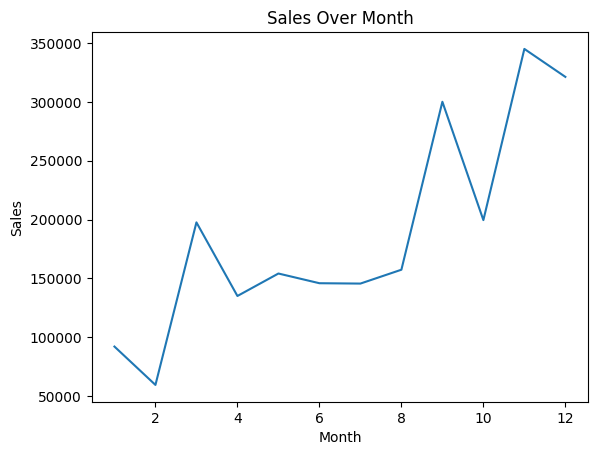

In [5]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

sns.lineplot(data=monthly_sales, x="Month", y="Sales")
plt.title("Sales Over Month")
plt.show()

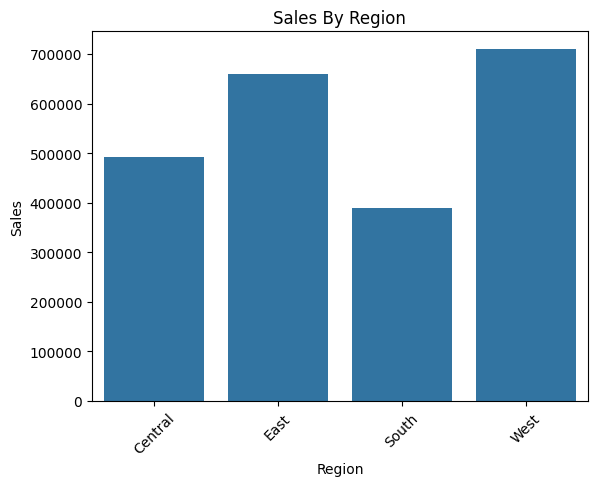

In [6]:
regional_sales = df.groupby("Region")["Sales"].sum().reset_index()

sns.barplot(data=regional_sales, x="Region", y="Sales")
plt.title("Sales By Region")
plt.xticks(rotation=45)
plt.show()

                                          Product Name      Sales
403              Canon imageCLASS 2200 Advanced Copier  61599.824
648  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
443  Cisco TelePresence System EX90 Videoconferenci...  22638.480
784       HON 5400 Series Task Chairs for Big and Tall  21870.576
684         GBC DocuBind TL300 Electric Binding System  19823.479
686   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
803               Hewlett Packard LaserJet 3310 Copier  18839.686
785  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
681          GBC DocuBind P400 Electric Binding System  17965.068
811        High Speed Automatic Electric Letter Opener  17030.312


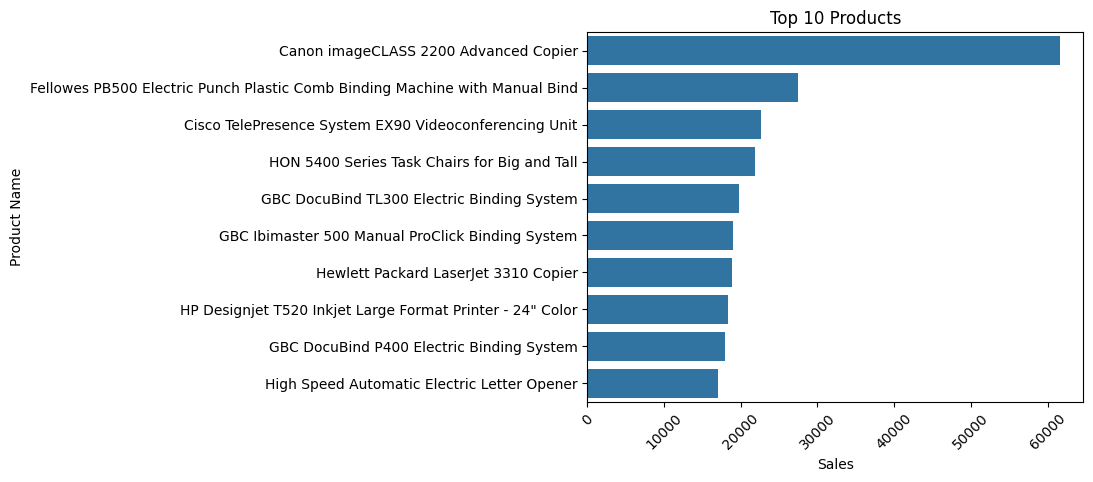

In [7]:
products = df.groupby('Product Name')['Sales'].sum().reset_index()
top_products = products.sort_values(by="Sales", ascending=False).head(10)

print(top_products)

sns.barplot(data=top_products,x="Sales", y="Product Name")
plt.title("Top 10 Products")
plt.xticks(rotation = 45)
plt.show()

## 📊 Key Business Insights

- Sales peak in November → recommend increasing inventory before festive season.
- Region South underperforms → suggests need for targeted marketing campaigns.
- Top 20% of products generate ~80% of total revenue (Pareto effect).

In [8]:
import sqlite3

conn = sqlite3.connect("sales.db")
df.to_sql("orders", conn, if_exists='replace', index=False)

query = """
SELECT Region, SUM(Sales) as total_sales
FROM orders
GROUP BY Region
"""

result = pd.read_sql(query, conn)
print(result)

    Region  total_sales
0  Central  492646.9132
1     East  660589.3560
2    South  389151.4590
3     West  710219.6845


## Machine Learning

Linear Regreesion


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["Month", "Year"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2 Score: ", r2)


MSE:  205902.7816521982
R2 Score:  -0.007009988361863506


Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df['High_Sales'] = (df['Sales'] > df['Sales'].median()).astype(int)

df[['Sales', 'High_Sales']].head()

X = df[['Month', 'Year']]
y = df['High_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.4938712972420838

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.48      0.49       977
           1       0.50      0.51      0.50       981

    accuracy                           0.49      1958
   macro avg       0.49      0.49      0.49      1958
weighted avg       0.49      0.49      0.49      1958


Confusion Matrix:
 [[469 508]
 [483 498]]
